# Part A — Loading and Understanding the Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Optional, but makes standard matplotlib plots look better

# Load the dataset (Assuming standard Iris dataset available in Kaggle/Scikit-learn or via CSV)
# If using a local CSV in Kaggle: df = pd.read_csv('/kaggle/input/iris/Iris.csv')
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# 1. Display first 5 rows
display(df.head())
# 2. Display last 5 rows
display(df.tail())
# 3. Number of rows and columns
print(f"Shape of dataset: {df.shape}")
# 4. Column names
print(f"Columns: {df.columns.tolist()}")
# 5. Data types
print(f"\nData Types:\n{df.dtypes}")
# 6. Basic statistical information
display(df.describe())
# 7. Different species present
print(f"\nUnique Species: {df['species'].unique()}")
# 8. Number of samples per species
print(f"\nSamples per species:\n{df['species'].value_counts()}")

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


Shape of dataset: (150, 5)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data Types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Unique Species: ['setosa' 'versicolor' 'virginica']

Samples per species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# Part B — Class-Agnostic Numerical Exploration

In [6]:
# Select only numerical columns before aggregation
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Calculate mean, min, max, and std for all numerical columns across the entire dataset
agnostic_stats = numeric_cols.agg(['mean', 'min', 'max', 'std'])
display(agnostic_stats)

,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.057333,3.758000,1.199333
min,4.300000,2.000000,1.000000,0.100000
max,7.900000,4.400000,6.900000,2.500000
std,0.828066,0.435866,1.765298,0.762238


# Part C — Class-Specific Exploration

In [7]:
# Group by species and calculate the mean for each feature
class_specific_means = df.groupby('species').mean()
display(class_specific_means)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


# Part D — Scatter Plot

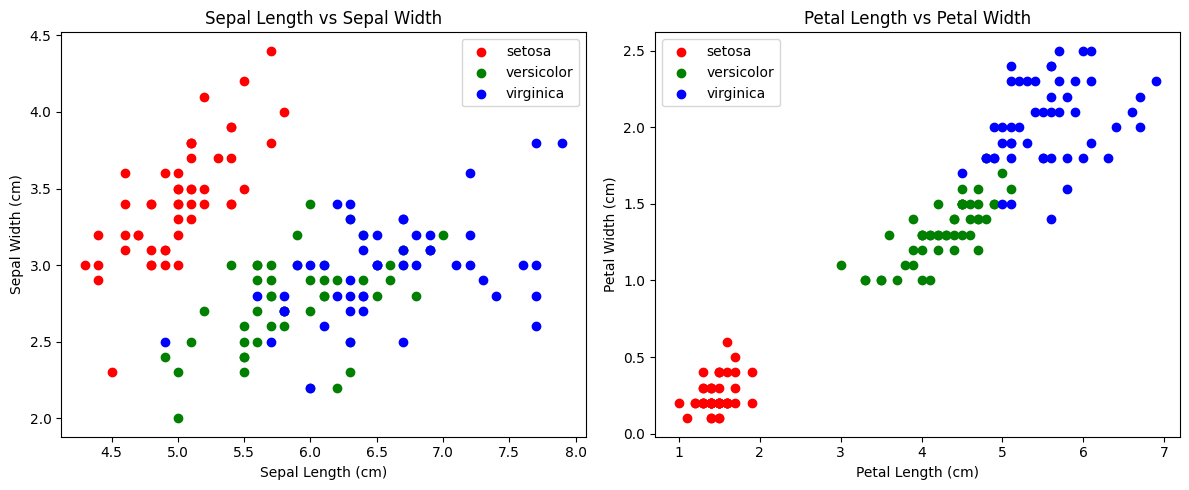

In [8]:
species_list = df['species'].unique()
colors = ['red', 'green', 'blue']

plt.figure(figsize=(12, 5))

# Plot 1: Sepal Length vs Sepal Width
plt.subplot(1, 2, 1)
for species, color in zip(species_list, colors):
    subset = df[df['species'] == species]
    plt.scatter(subset['sepal_length'], subset['sepal_width'], c=color, label=species)
plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()

# Plot 2: Petal Length vs Petal Width
plt.subplot(1, 2, 2)
for species, color in zip(species_list, colors):
    subset = df[df['species'] == species]
    plt.scatter(subset['petal_length'], subset['petal_width'], c=color, label=species)
plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()

plt.tight_layout()
plt.show()

# Part E — Histograms

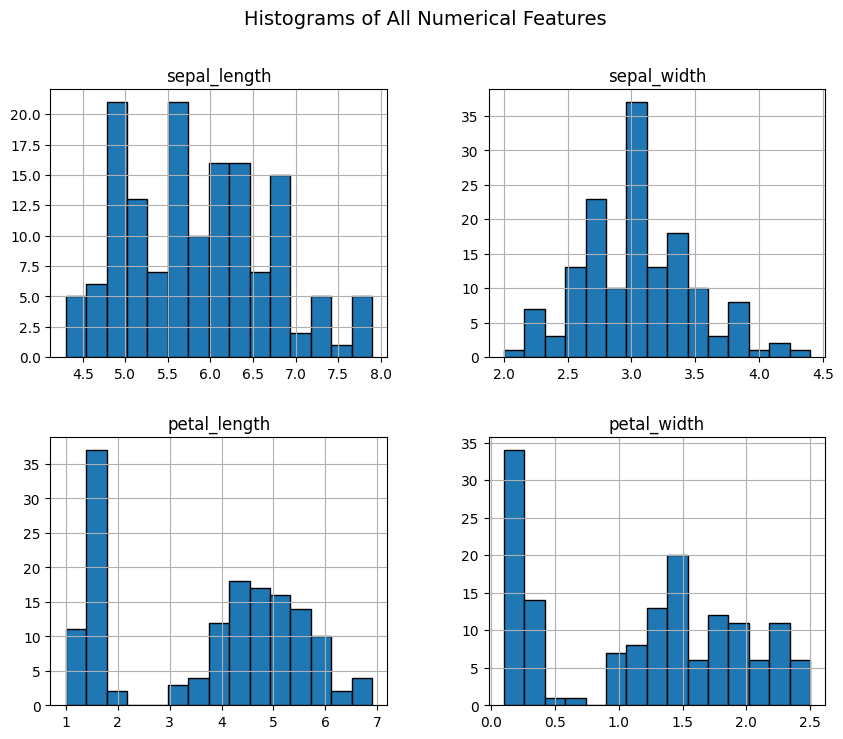

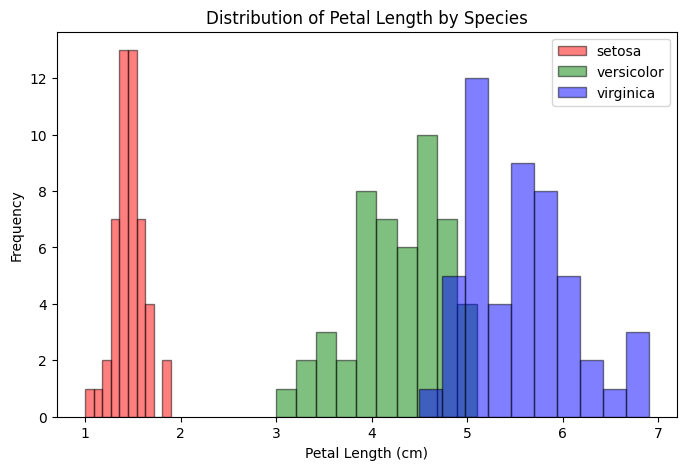

In [9]:
# 1-4. Histograms of all numerical features
df.hist(figsize=(10, 8), bins=15, edgecolor='black')
plt.suptitle('Histograms of All Numerical Features', fontsize=14)
plt.show()

# Class-specific histogram for Petal Length
plt.figure(figsize=(8, 5))
for species, color in zip(species_list, colors):
    subset = df[df['species'] == species]
    plt.hist(subset['petal_length'], bins=10, alpha=0.5, label=species, color=color, edgecolor='black')
plt.title('Distribution of Petal Length by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')
plt.legend()
plt.show()